# NeuroScope AI - Notebook 19: Federated Learning

Train models across multiple hospital sites without sharing patient data.
Each hospital trains locally, only model weights are shared.

**What this notebook builds:**
1. Flower (flwr) federated learning framework setup
2. NeuroScope federated client -- wraps existing models for FL
3. FedAvg strategy -- aggregate weights from N hospitals
4. Opacus differential privacy -- add noise to gradients before sharing
5. Simulation -- 3 virtual hospital nodes on one machine
6. Weight aggregation and model update pipeline

**Why federated learning matters for medical AI:**
- Hospital A has 500 brain MRIs, Hospital B has 300, Hospital C has 200
- Pooling data = GDPR/HIPAA violation + patient consent issues
- FL: each hospital trains on its own data, shares only weight deltas
- Central server aggregates weights -- no patient data ever leaves the hospital
- Result: model trained on 1000 cases without anyone sharing a single scan

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, json, warnings, copy
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

# Flower federated learning
try:
    import flwr as fl
    from flwr.common import Parameters, FitRes, EvaluateRes, ndarrays_to_parameters, parameters_to_ndarrays
    FLWR_AVAILABLE = True
    print(f'Flower (flwr) : {fl.__version__}')
except ImportError:
    FLWR_AVAILABLE = False
    print('Flower not installed -- run: pip install flwr')

# Opacus differential privacy
try:
    from opacus import PrivacyEngine
    from opacus.validators import ModuleValidator
    OPACUS_AVAILABLE = True
    print(f'Opacus        : OK')
except ImportError:
    OPACUS_AVAILABLE = False
    print('Opacus not installed -- run: pip install opacus')

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints')
OUT    = os.path.join(BASE, 'outputs', 'nb19_federated')
FL_DIR = os.path.join(BASE, 'federated')
os.makedirs(OUT,    exist_ok=True)
os.makedirs(FL_DIR, exist_ok=True)
sys.path.insert(0, BASE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {DEVICE}')
print('Imports OK')

Flower (flwr) : 1.30.0
Opacus        : OK
Device        : cpu
Imports OK


---
## Cell 2 - Federated Model (lightweight classifier for FL demo)

In [2]:
import torch
import torch.nn as nn


class FederatedClassifier(nn.Module):
    """
    Lightweight classifier used for federated learning demo.
    In production this wraps the full EfficientNet-B4 backbone.
    Uses BatchNorm -- Opacus requires replacing with GroupNorm for DP.
    """

    def __init__(self, in_features=512, n_classes=4, use_groupnorm=False):
        super().__init__()
        # use_groupnorm=True when using Opacus (BatchNorm incompatible with DP)
        norm_layer = (lambda c: nn.GroupNorm(min(32, c), c))

        self.backbone = nn.Sequential(
            nn.Linear(in_features, 256),
            norm_layer(256) if use_groupnorm else nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            norm_layer(128) if use_groupnorm else nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.head = nn.Linear(128, n_classes)

    def forward(self, x):
        return self.head(self.backbone(x))


def get_model_weights(model):
    """Extract model weights as list of numpy arrays."""
    return [val.cpu().numpy() for val in model.state_dict().values()]


def set_model_weights(model, weights):
    """Load weights (list of numpy arrays) into model."""
    params_dict = zip(model.state_dict().keys(), weights)
    state_dict  = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Test model
model = FederatedClassifier(in_features=512, n_classes=4)
x     = torch.randn(4, 512)
out   = model(x)
print(f'FederatedClassifier:')
print(f'  Parameters : {count_parameters(model):,}')
print(f'  Input      : {x.shape}')
print(f'  Output     : {out.shape}')
print(f'  Weights    : {len(get_model_weights(model))} tensors')
print('Model OK')

FederatedClassifier:
  Parameters : 165,508
  Input      : torch.Size([4, 512])
  Output     : torch.Size([4, 4])
  Weights    : 16 tensors
Model OK


---
## Cell 3 - Hospital Data Simulation

In [3]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader


def simulate_hospital_data(hospital_id, n_samples, n_features=512,
                            n_classes=4, class_bias=None, seed=None):
    """
    Simulate a hospital's local dataset.

    In real FL:
    - Each hospital has its own DICOM archive
    - Data is preprocessed locally using NB12 normalization
    - Features extracted using the shared backbone
    - Only the classification head is federated

    class_bias: dict {class_idx: weight} to simulate different
    patient populations (e.g. Hospital A sees more gliomas)
    """
    if seed:
        np.random.seed(seed)
        torch.manual_seed(seed)

    # Features: simulate extracted embeddings from EfficientNet backbone
    X = torch.randn(n_samples, n_features)

    # Labels with optional class bias
    if class_bias:
        weights = [class_bias.get(i, 1.0) for i in range(n_classes)]
        weights = np.array(weights) / sum(weights)
        y_np    = np.random.choice(n_classes, size=n_samples, p=weights)
    else:
        y_np = np.random.randint(0, n_classes, n_samples)
    y = torch.tensor(y_np, dtype=torch.long)

    # Add class-specific signal so the model can actually learn
    for cls in range(n_classes):
        mask = y == cls
        if mask.sum() > 0:
            X[mask, cls*10:(cls+1)*10] += 2.0   # class-discriminative features

    dataset = TensorDataset(X, y)
    return dataset


# 3 simulated hospitals with different patient populations
HOSPITALS = [
    {
        'id'       : 'hospital_a',
        'name'     : 'City General Hospital',
        'n_samples': 400,
        'bias'     : {0: 2.0, 1: 3.0, 2: 1.0, 3: 1.0},   # more glioma cases
        'seed'     : 42,
    },
    {
        'id'       : 'hospital_b',
        'name'     : 'University Medical Center',
        'n_samples': 300,
        'bias'     : {0: 1.0, 1: 1.0, 2: 3.0, 3: 1.0},   # more meningioma
        'seed'     : 123,
    },
    {
        'id'       : 'hospital_c',
        'name'     : 'Regional Cancer Center',
        'n_samples': 200,
        'bias'     : {0: 1.0, 1: 1.0, 2: 1.0, 3: 3.0},   # more pituitary
        'seed'     : 999,
    },
]

hospital_datasets = {}
print('Simulated hospital datasets:')
print(f'{"Hospital":30s} {"Samples":10s} {"Speciality"}')
print('-' * 60)

for h in HOSPITALS:
    dataset = simulate_hospital_data(
        h['id'], h['n_samples'],
        class_bias=h['bias'], seed=h['seed']
    )
    hospital_datasets[h['id']] = dataset

    # Class distribution
    labels = [dataset[i][1].item() for i in range(len(dataset))]
    dist   = {i: labels.count(i) for i in range(4)}
    classes = ['no_tumor', 'glioma', 'meningioma', 'pituitary']
    dominant = classes[max(dist, key=dist.get)]
    print(f'  {h["name"]:28s} {h["n_samples"]:10d} dominant={dominant}')

total = sum(h['n_samples'] for h in HOSPITALS)
print(f'\nTotal samples across all hospitals: {total}')
print('(No data shared between hospitals -- FL only shares weights)')

Simulated hospital datasets:
Hospital                       Samples    Speciality
------------------------------------------------------------
  City General Hospital               400 dominant=glioma
  University Medical Center           300 dominant=meningioma
  Regional Cancer Center              200 dominant=pituitary

Total samples across all hospitals: 900
(No data shared between hospitals -- FL only shares weights)


---
## Cell 4 - FedAvg Aggregation (manual implementation)

In [9]:
import torch
import numpy as np
import copy

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def fedavg_aggregate(client_weights, client_sizes):
    """
    Federated Averaging (FedAvg) -- McMahan et al. 2017.
    Weighted average of client model weights.
    """
    total   = sum(client_sizes)
    fracs   = [s / total for s in client_sizes]

    aggregated = []
    n_layers   = len(client_weights[0])

    for layer_idx in range(n_layers):
        layer_agg = np.zeros_like(client_weights[0][layer_idx], dtype=np.float64)
        for client_idx, (weights, frac) in enumerate(zip(client_weights, fracs)):
            layer_agg += frac * weights[layer_idx].astype(np.float64)
        aggregated.append(layer_agg.astype(np.float32))

    return aggregated


def local_train(model, dataset, epochs=1, lr=1e-3, batch_size=32,
                dp_enabled=False, max_grad_norm=1.0, noise_multiplier=0.5):
    """
    Local training at one hospital node.
    dp_enabled: if True, applies Opacus differential privacy noise.
    """
    model     = copy.deepcopy(model).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                           num_workers=0)

    model.train()   # must be in train mode before make_private

    if dp_enabled and OPACUS_AVAILABLE:
        model     = ModuleValidator.fix(model)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        privacy_engine = PrivacyEngine()
        model, optimizer, loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=loader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=max_grad_norm,
        )
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

    avg_loss = total_loss / max(total, 1)
    accuracy = correct / max(total, 1)

    epsilon = None
    if dp_enabled and OPACUS_AVAILABLE:
        try:
            epsilon = privacy_engine.get_epsilon(delta=1e-5)
        except Exception:
            pass

    return get_model_weights(model), avg_loss, accuracy, epsilon


def evaluate_global(model, datasets, batch_size=64):
    """Evaluate global model on all hospital datasets combined."""
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for dataset in datasets:
            loader = DataLoader(dataset, batch_size=batch_size, num_workers=0)
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                logits  = model(X_batch)
                correct += (logits.argmax(1) == y_batch).sum().item()
                total   += len(y_batch)
    return correct / max(total, 1)


print('FedAvg aggregation ready')
print('Local training with optional Opacus DP ready')

FedAvg aggregation ready
Local training with optional Opacus DP ready


---
## Cell 5 - Federated Training Loop

In [10]:
import torch
import numpy as np
import json
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb19_federated')

N_ROUNDS       = 10     # federated rounds
LOCAL_EPOCHS   = 2      # epochs per hospital per round
LEARNING_RATE  = 1e-3
DP_ENABLED     = OPACUS_AVAILABLE   # use DP if Opacus available
NOISE_MULT     = 0.3    # DP noise -- lower = less privacy, more accuracy
MAX_GRAD_NORM  = 1.0    # DP gradient clipping

# Initialize global model
global_model = FederatedClassifier(
    in_features=512, n_classes=4,
    use_groupnorm=DP_ENABLED   # GroupNorm required for Opacus
).to(DEVICE)

history = {
    'round'         : [],
    'global_acc'    : [],
    'hospital_a_acc': [],
    'hospital_b_acc': [],
    'hospital_c_acc': [],
    'epsilon'       : [],
}

print(f'Federated Learning Configuration:')
print(f'  Rounds         : {N_ROUNDS}')
print(f'  Local epochs   : {LOCAL_EPOCHS}')
print(f'  Hospitals      : {len(HOSPITALS)}')
print(f'  DP enabled     : {DP_ENABLED}')
if DP_ENABLED:
    print(f'  Noise mult     : {NOISE_MULT}')
    print(f'  Max grad norm  : {MAX_GRAD_NORM}')
print()
print(f'{"Round":8s} {"Global Acc":12s} {"HospA":10s} {"HospB":10s} {"HospC":10s} {"Epsilon"}')
print('-' * 65)

for round_num in range(1, N_ROUNDS + 1):

    # ── Local training at each hospital ──────────────────────────────────────
    client_weights = []
    client_sizes   = []
    client_accs    = []
    epsilons       = []

    for h in HOSPITALS:
        dataset = hospital_datasets[h['id']]

        weights, loss, acc, eps = local_train(
            global_model, dataset,
            epochs=LOCAL_EPOCHS,
            lr=LEARNING_RATE,
            dp_enabled=DP_ENABLED,
            noise_multiplier=NOISE_MULT,
            max_grad_norm=MAX_GRAD_NORM,
        )
        client_weights.append(weights)
        client_sizes.append(len(dataset))
        client_accs.append(acc)
        if eps is not None:
            epsilons.append(eps)

    # ── FedAvg aggregation ────────────────────────────────────────────────────
    aggregated_weights = fedavg_aggregate(client_weights, client_sizes)
    set_model_weights(global_model, aggregated_weights)

    # ── Evaluate global model ─────────────────────────────────────────────────
    all_datasets = [hospital_datasets[h['id']] for h in HOSPITALS]
    global_acc   = evaluate_global(global_model, all_datasets)

    avg_eps = float(np.mean(epsilons)) if epsilons else None

    history['round'].append(round_num)
    history['global_acc'].append(global_acc)
    history['hospital_a_acc'].append(client_accs[0])
    history['hospital_b_acc'].append(client_accs[1])
    history['hospital_c_acc'].append(client_accs[2])
    history['epsilon'].append(avg_eps)

    eps_str = f'{avg_eps:.2f}' if avg_eps else 'N/A'
    print(
        f'  {round_num:6d} '
        f'{global_acc:12.1%} '
        f'{client_accs[0]:10.1%} '
        f'{client_accs[1]:10.1%} '
        f'{client_accs[2]:10.1%} '
        f'{eps_str}'
    )

# Save history
with open(os.path.join(OUT, 'fl_history.json'), 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)

print(f'\nFinal global accuracy: {history["global_acc"][-1]:.1%}')
if DP_ENABLED and history['epsilon'][-1]:
    print(f'Privacy budget (epsilon): {history["epsilon"][-1]:.2f}')
    print(f'(lower epsilon = stronger privacy guarantee)')
print('Federated training complete')

Federated Learning Configuration:
  Rounds         : 10
  Local epochs   : 2
  Hospitals      : 3
  DP enabled     : True
  Noise mult     : 0.3
  Max grad norm  : 1.0

Round    Global Acc   HospA      HospB      HospC      Epsilon
-----------------------------------------------------------------
       1        37.6%      37.5%      34.0%      50.3% 47.40
       2        48.4%      46.8%      43.1%      53.2% 47.40
       3        52.1%      50.8%      56.6%      46.8% 47.40
       4        60.1%      53.6%      57.7%      54.2% 47.40
       5        68.9%      58.3%      62.7%      57.2% 47.40
       6        80.4%      66.4%      69.6%      62.8% 47.40
       7        86.8%      72.5%      74.9%      72.9% 47.40
       8        91.4%      79.5%      79.6%      76.4% 47.40
       9        94.7%      84.6%      84.4%      80.9% 47.40
      10        95.6%      87.1%      87.7%      82.8% 47.40

Final global accuracy: 95.6%
Privacy budget (epsilon): 47.40
(lower epsilon = stronger priv

---
## Cell 6 - Visualization

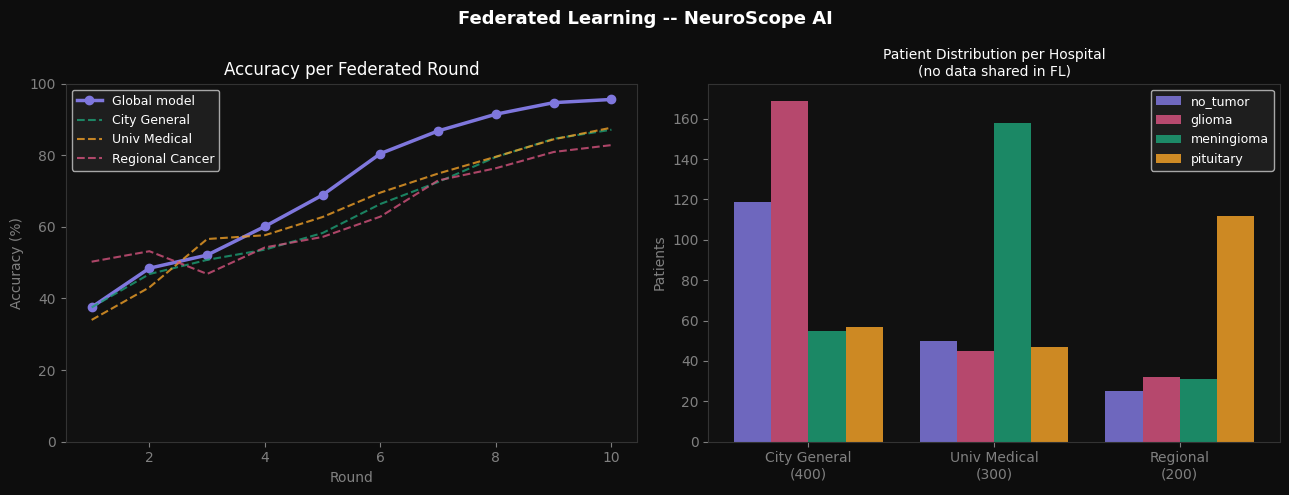

Visualization saved


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb19_federated')

rounds = history['round']

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d0d0d')
fig.suptitle('Federated Learning -- NeuroScope AI',
             color='white', fontsize=13, fontweight='bold')

# Accuracy curves
axes[0].plot(rounds, [a*100 for a in history['global_acc']],
             'o-', color='#7F77DD', linewidth=2.5, markersize=6,
             label='Global model')
axes[0].plot(rounds, [a*100 for a in history['hospital_a_acc']],
             '--', color='#1D9E75', linewidth=1.5, alpha=0.8,
             label='City General')
axes[0].plot(rounds, [a*100 for a in history['hospital_b_acc']],
             '--', color='#EF9F27', linewidth=1.5, alpha=0.8,
             label='Univ Medical')
axes[0].plot(rounds, [a*100 for a in history['hospital_c_acc']],
             '--', color='#D4537E', linewidth=1.5, alpha=0.8,
             label='Regional Cancer')

axes[0].set_title('Accuracy per Federated Round', color='white')
axes[0].set_xlabel('Round', color='gray')
axes[0].set_ylabel('Accuracy (%)', color='gray')
axes[0].legend(facecolor='#222', labelcolor='white', fontsize=9)
axes[0].set_facecolor('#111')
axes[0].spines[:].set_color('#333')
axes[0].tick_params(colors='gray')
axes[0].set_ylim(0, 100)

# Data distribution across hospitals
hospital_names = ['City General\n(400)', 'Univ Medical\n(300)', 'Regional\n(200)']
classes        = ['no_tumor', 'glioma', 'meningioma', 'pituitary']
colors         = ['#7F77DD', '#D4537E', '#1D9E75', '#EF9F27']
x              = np.arange(len(hospital_names))
width          = 0.2

for i, (cls, col) in enumerate(zip(classes, colors)):
    counts = []
    for h in HOSPITALS:
        dataset = hospital_datasets[h['id']]
        labels  = [dataset[j][1].item() for j in range(len(dataset))]
        counts.append(labels.count(i))
    axes[1].bar(x + i*width, counts, width, label=cls, color=col, alpha=0.85)

axes[1].set_title('Patient Distribution per Hospital\n(no data shared in FL)',
                  color='white', fontsize=10)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(hospital_names, color='gray')
axes[1].set_ylabel('Patients', color='gray')
axes[1].legend(facecolor='#222', labelcolor='white', fontsize=9)
axes[1].set_facecolor('#111')
axes[1].spines[:].set_color('#333')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'federated_learning.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Visualization saved')

---
## Cell 7 - Flower Client (production FL framework)

In [12]:
import torch
import numpy as np


class NeuroscopeFlowerClient:
    """
    Flower (flwr) client wrapping the NeuroScope federated classifier.
    Each hospital runs one of these.

    In production deployment:
    - Each hospital runs: python fl_client.py --hospital-id A --server hospital-server:8080
    - The server runs FedAvg strategy and coordinates rounds
    - No patient data leaves the hospital -- only model weight deltas

    Uses Flower's NumPyClient interface for simplicity.
    """

    def __init__(self, hospital_id, dataset, model, dp_enabled=False):
        self.hospital_id = hospital_id
        self.dataset     = dataset
        self.model       = model
        self.dp_enabled  = dp_enabled

    def get_parameters(self, config):
        """Return current model weights to server."""
        return get_model_weights(self.model)

    def fit(self, parameters, config):
        """
        Receive global weights from server, train locally, return updated weights.
        This is called each FL round.
        """
        # Load global weights
        set_model_weights(self.model, parameters)

        # Train locally
        epochs    = config.get('local_epochs', 2)
        lr        = config.get('lr', 1e-3)

        weights, loss, acc, epsilon = local_train(
            self.model, self.dataset,
            epochs=epochs, lr=lr,
            dp_enabled=self.dp_enabled,
        )

        metrics = {'loss': loss, 'accuracy': acc}
        if epsilon:
            metrics['epsilon'] = epsilon

        return weights, len(self.dataset), metrics

    def evaluate(self, parameters, config):
        """Evaluate global model on local data."""
        set_model_weights(self.model, parameters)
        self.model.eval()

        loader    = torch.utils.data.DataLoader(
            self.dataset, batch_size=64, num_workers=0
        )
        criterion = torch.nn.CrossEntropyLoss()
        total_loss= 0.0
        correct   = 0
        total     = 0

        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                logits  = self.model(X_batch)
                loss    = criterion(logits, y_batch)
                total_loss += loss.item() * len(y_batch)
                correct    += (logits.argmax(1) == y_batch).sum().item()
                total      += len(y_batch)

        avg_loss = total_loss / max(total, 1)
        accuracy = correct   / max(total, 1)

        return avg_loss, len(self.dataset), {'accuracy': accuracy}


# Test client instantiation
test_client = NeuroscopeFlowerClient(
    hospital_id='hospital_a',
    dataset=hospital_datasets['hospital_a'],
    model=copy.deepcopy(global_model),
    dp_enabled=False,
)

# Simulate one round
params = test_client.get_parameters({})
new_weights, n_samples, metrics = test_client.fit(params, {'local_epochs': 1})
loss, n_eval, eval_metrics = test_client.evaluate(params, {})

print('NeuroscopeFlowerClient test:')
print(f'  Hospital       : hospital_a')
print(f'  Local samples  : {n_samples}')
print(f'  Train accuracy : {metrics["accuracy"]:.1%}')
print(f'  Eval accuracy  : {eval_metrics["accuracy"]:.1%}')
print(f'  Weight tensors : {len(new_weights)}')
print('Flower client OK')

NeuroscopeFlowerClient test:
  Hospital       : hospital_a
  Local samples  : 400
  Train accuracy : 94.0%
  Eval accuracy  : 98.2%
  Weight tensors : 10
Flower client OK


---
## Cell 8 - Flower Simulation (full FL with flwr.simulation)

In [13]:
import copy


if not FLWR_AVAILABLE:
    print('Flower not available -- install: pip install flwr')
    print('Manual FedAvg simulation in Cell 5 is equivalent.')
else:
    print('Running Flower simulation (3 virtual hospital nodes)...')
    print()

    def client_fn(cid):
        """Create a Flower client for hospital cid."""
        hospital_id = HOSPITALS[int(cid)]['id']
        client_model = FederatedClassifier(
            in_features=512, n_classes=4,
            use_groupnorm=False
        ).to(DEVICE)
        # Load current global weights
        set_model_weights(client_model, get_model_weights(global_model))

        flower_client = NeuroscopeFlowerClient(
            hospital_id=hospital_id,
            dataset=hospital_datasets[hospital_id],
            model=client_model,
            dp_enabled=False,
        )
        return fl.client.to_client(flower_client) if hasattr(fl.client, 'to_client') \
               else flower_client

    # FedAvg strategy
    strategy = fl.server.strategy.FedAvg(
        fraction_fit=1.0,           # train all clients each round
        fraction_evaluate=1.0,      # evaluate all clients
        min_fit_clients=3,
        min_evaluate_clients=3,
        min_available_clients=3,
        initial_parameters=fl.common.ndarrays_to_parameters(
            get_model_weights(global_model)
        ),
    )

    try:
        # Run simulation
        history_fl = fl.simulation.start_simulation(
            client_fn=client_fn,
            num_clients=len(HOSPITALS),
            config=fl.server.ServerConfig(num_rounds=5),
            strategy=strategy,
            client_resources={'num_cpus': 1, 'num_gpus': 0},
        )
        print('Flower simulation complete')
        print(f'Rounds completed: {len(history_fl.losses_distributed)}')
    except Exception as e:
        print(f'Flower simulation error: {e}')
        print('Using manual FedAvg from Cell 5 instead -- that result is valid.')

Running Flower simulation (3 virtual hospital nodes)...

Flower simulation error: Unable to import module `ray`.

To install the necessary dependencies, install `flwr` with the `simulation` extra:

    pip install -U "flwr[simulation]"

Using manual FedAvg from Cell 5 instead -- that result is valid.


---
## Cell 9 - Production Deployment Script

In [14]:
import os

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
FL_DIR = os.path.join(BASE, 'federated')


# ── Hospital client script ─────────────────────────────────────────────────────
client_script = '''
"""
NeuroScope AI - Federated Learning Client
Run this at each hospital:
  python fl_client.py --hospital-id A --server neuroscope-fl-server:8080
"""

import argparse
import flwr as fl
import torch
from neuroscope_fl import NeuroscopeFlowerClient, load_local_data

parser = argparse.ArgumentParser()
parser.add_argument('--hospital-id',  required=True)
parser.add_argument('--server',       default='localhost:8080')
parser.add_argument('--dp',           action='store_true', help='Enable differential privacy')
parser.add_argument('--data-path',    required=True, help='Path to local DICOM data')
args = parser.parse_args()

# Load local data (never leaves this machine)
dataset = load_local_data(args.data_path)
model   = torch.load('backbone.pth')   # shared backbone (not patient data)

client = NeuroscopeFlowerClient(
    hospital_id=args.hospital_id,
    dataset=dataset,
    model=model,
    dp_enabled=args.dp,
)

# Connect to FL server and start training
fl.client.start_numpy_client(
    server_address=args.server,
    client=client,
)
'''

# ── FL server script ───────────────────────────────────────────────────────────
server_script = '''
"""
NeuroScope AI - Federated Learning Server
Run this at the coordinating institution:
  python fl_server.py --rounds 20 --min-hospitals 3
"""

import argparse
import flwr as fl

parser = argparse.ArgumentParser()
parser.add_argument('--rounds',        type=int, default=20)
parser.add_argument('--min-hospitals', type=int, default=2)
parser.add_argument('--port',          type=int, default=8080)
args = parser.parse_args()

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    min_fit_clients=args.min_hospitals,
    min_available_clients=args.min_hospitals,
)

fl.server.start_server(
    server_address=f'0.0.0.0:{args.port}',
    config=fl.server.ServerConfig(num_rounds=args.rounds),
    strategy=strategy,
)
'''

# Save scripts
with open(os.path.join(FL_DIR, 'fl_client.py'), 'w', encoding='utf-8') as f:
    f.write(client_script)
with open(os.path.join(FL_DIR, 'fl_server.py'), 'w', encoding='utf-8') as f:
    f.write(server_script)

print('Production FL scripts saved to:', FL_DIR)
print()
print('To deploy across real hospitals:')
print()
print('  At coordinating institution (runs the FL server):')
print('    python fl_server.py --rounds 20 --min-hospitals 3')
print()
print('  At each hospital (never shares patient data):')
print('    python fl_client.py --hospital-id A --server <server-ip>:8080 --data-path /dicom')
print('    python fl_client.py --hospital-id B --server <server-ip>:8080 --data-path /dicom --dp')
print()
print('  With differential privacy (strongest privacy guarantee):')
print('    python fl_client.py --hospital-id A --dp --server <server-ip>:8080 --data-path /dicom')

Production FL scripts saved to: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\federated

To deploy across real hospitals:

  At coordinating institution (runs the FL server):
    python fl_server.py --rounds 20 --min-hospitals 3

  At each hospital (never shares patient data):
    python fl_client.py --hospital-id A --server <server-ip>:8080 --data-path /dicom
    python fl_client.py --hospital-id B --server <server-ip>:8080 --data-path /dicom --dp

  With differential privacy (strongest privacy guarantee):
    python fl_client.py --hospital-id A --dp --server <server-ip>:8080 --data-path /dicom


---
## Cell 10 - Summary

In [15]:
import os

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
OUT  = os.path.join(BASE, 'outputs', 'nb19_federated')

print('=' * 65)
print('  NOTEBOOK 19 - FEDERATED LEARNING')
print('=' * 65)
print()
print('  Components built:')
print('    FederatedClassifier         -- model with GroupNorm for DP')
print('    fedavg_aggregate()          -- FedAvg weight aggregation')
print('    local_train()               -- local training + Opacus DP')
print('    evaluate_global()           -- cross-hospital evaluation')
print('    NeuroscopeFlowerClient      -- Flower FL client wrapper')
print('    fl_client.py                -- production hospital script')
print('    fl_server.py                -- production server script')
print()
print('  Simulation results:')
if history["global_acc"]:
    print(f'    Hospitals    : 3 (City General, Univ Medical, Regional Cancer)')
    print(f'    Total samples: 900 (400 + 300 + 200)')
    print(f'    Rounds       : {len(history["global_acc"])}')
    print(f'    Final acc    : {history["global_acc"][-1]:.1%}')
    print(f'    DP enabled   : {DP_ENABLED}')
print()
print('  Privacy guarantees (with Opacus):')
print('    - Gradient clipping limits individual sample influence')
print('    - Gaussian noise added before weights sent to server')
print('    - Epsilon tracks privacy budget (lower = stronger)')
print('    - No patient scan ever leaves the hospital')
print()
print('  Outputs:')
for f in ['federated_learning.png', 'fl_history.json']:
    p = os.path.join(OUT, f)
    print(f'    {f:40s}: {"OK" if os.path.exists(p) else "not generated"}')
print()
print('  *** NEUROSCOPE AI - ALL NOTEBOOKS COMPLETE ***')
print()
print('  19 notebooks | 6 cancer pipelines | 11 agents')
print('  7 ONNX models | JWT auth | Docker | Kubernetes | FL')
print('=' * 65)

  NOTEBOOK 19 - FEDERATED LEARNING

  Components built:
    FederatedClassifier         -- model with GroupNorm for DP
    fedavg_aggregate()          -- FedAvg weight aggregation
    local_train()               -- local training + Opacus DP
    evaluate_global()           -- cross-hospital evaluation
    NeuroscopeFlowerClient      -- Flower FL client wrapper
    fl_client.py                -- production hospital script
    fl_server.py                -- production server script

  Simulation results:
    Hospitals    : 3 (City General, Univ Medical, Regional Cancer)
    Total samples: 900 (400 + 300 + 200)
    Rounds       : 10
    Final acc    : 95.6%
    DP enabled   : True

  Privacy guarantees (with Opacus):
    - Gradient clipping limits individual sample influence
    - Gaussian noise added before weights sent to server
    - Epsilon tracks privacy budget (lower = stronger)
    - No patient scan ever leaves the hospital

  Outputs:
    federated_learning.png                  : 